## Обучение модели логистической регрессии

# 1. Импорт данных
Давайте потренируемся в применении логистической регрессии на датасете Titanic из seaborn.

In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


1. Survived
Первый признак показывал, выжил ли пассажир или умер.

2. Pclass
Этот признак показывает класс, которым следовал пассажир. Пассажиры могли выбрать из трех отдельных классов, а именно: класс 1, класс 2 и класс 3. Третий класс имел наибольшее количество пассажиров, затем класс 2 и класс 1.

3. Sex
Примерно 65% пассажиров составляли мужчины, а остальные 35% — женщины.

4. Age
Самому молодому путешественнику на борту было около двух месяцев, а самому старшему — 80 лет.

5. SibSp
SibSp — это число братьев, сестер или супругов на борту у человека.

6. Parch
Подобно SibSp, этот признак содержал количество родителей или детей, с которыми путешествовал каждый пассажир.

7. Fare
Разделив сумму тарифа на четыре категории, стало очевидно, что существует тесная связь между стоимостью тарифа и выживанием.

8. Embarked
Этот столбец хранит информацию о порте посадки пассажира. Есть три возможных значения для Embarked -  Саутгемптон, Шербург и Куинстаун.

# 2. Информация о датасете
Посмотрим на сам датасет

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Посмотрим на уникальные значения в категориальных признаках

In [3]:
df.describe(include = ['object'])

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [4]:
df.isna().sum() / df.shape[0]

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

# 3. Работа с признаками

Удалим признак alive, так как он повторяет survived

Удалим также deck, так как в нем порядка 77% пропусков, что уже довольно неинформативно, лучше плохозаполненные такие признаки

Дополнительно заполним пропуски модой (самое простое для учебного примера)

Сделаем One-Hot преобразование при помощи pandas (не забывайте про drop_first=True, см. лекцию Введение в машинное обучение)


In [5]:
# удаление признаков
df.drop(columns=['alive', 'deck'], inplace=True)
# заполнение пропусков модой
df.fillna(df.mode().iloc[0], inplace=True)
df_label = pd.get_dummies(df, drop_first=True)
df_label.head()

<ipython-input-5-9033c6976977>:4: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df.fillna(df.mode().iloc[0], inplace=True)


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,True,False,1,0,1,0,1,1,0,0,1
1,1,1,38.0,1,0,71.2833,False,False,0,0,0,0,0,0,1,0,0
2,1,3,26.0,0,0,7.9250,False,True,0,0,1,0,1,0,1,0,1
3,1,1,35.0,1,0,53.1000,False,False,0,0,1,0,0,0,1,0,1
4,0,3,35.0,0,0,8.0500,True,True,1,0,1,0,1,1,0,0,1


# 4. Обучение модели

Разобьем данные на тренировочные и тестовые, чтобы мы смогли потом оценить работу модели и обучим логистическую регрессию, модель которой уже есть в библиотеке scikit-learn. Также нам необходимо стандартизовать данные после разбиения.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


X = df_label.drop('survived', axis=1)
y = df_label['survived']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    stratify=y,
                                                    test_size=0.2,
                                                    random_state=42)

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

clf = LogisticRegression()
clf.fit(X_train_std, y_train)

LogisticRegression()

# 5. Интерпретация модели

Предлагаю теперь посмотреть, как признаки влияют на целевую переменную. Для этого посмотрим на значение каждого из весов при помощи атрибута coef_

In [7]:
df_coefs = pd.DataFrame(data=clf.coef_, columns=X.columns).T
df_coefs.columns = ['Coeffecient']
df_coefs

,Coeffecient
pclass,-0.529999
age,-0.253000
sibsp,-0.575095
parch,-0.268571
fare,0.121139
adult_male,-0.685519
alone,-0.252337
sex_male,-0.109862
embarked_Q,0.029436
embarked_S,-0.072038


# ВЫВОД:

Если пассажир был взрослым мужчиной, то это уменьшает логарифм шанса выживания на борту на 0.685
Если пассажир садился в порту Queenstown, то это увеличивает логарифм шанса выживания на борту на 0.029

## Обучение модели логистической регрессии
# Дополнительный материал по интерпретации

Продолжаем работать все с тем же датасетом и предобученной моделью из прошлого шага. Давайте посмотрим как значение весов влияет на вероятность выжить в цифрах. Для примера возьмем первую строку из X_train датасета и умножим на значения весов и свободный коэффициент - атрибут intercept_

In [9]:
# возьмем первую строку из X_test_std
example_data = X_test_std[0].copy()
X_test.head(1)

,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton
565,3,24.0,2,0,24.15,True,False,1,0,1,0,1,1,0,0,1


In [11]:
# расчитаем вероятность выжить
# умножив получившиеся коэф на соответ значения признаков
import numpy as np
z = clf.intercept_ + sum(clf.coef_[0] * example_data)
risk = 1 / (1 + np.exp(-z[0]))

print(
    f"Вероятность выжить = {round(risk, 3)}, в процентах = {round(risk*100, 2)}%")

Вероятность выжить = 0.047, в процентах = 4.74%


Видим, что довольно низкий процент выживаемости, скорее всего, человек погибнет, так как risk < 0.5. Давайте увеличим значение признака age на единицу, так как коэффициент при этом признаке равен -0.253 (см. прошлый шаг), то по идее с увеличением данного признака, уменьшается логарифм шанса выжить на это же число. Проверяем

In [12]:
# Попробуем увеличить значенение признака age на единицу
# уже в нормализованных данных
example_data[1] += 1

example_rev = sc.inverse_transform(pd.DataFrame(example_data).T)
print(f'Разница в возрасте: {example_rev[0][1] - X_test.iloc[0][1]}')


# снова рассчитаем вероятности
z_change = clf.intercept_ + sum(clf.coef_[0] * example_data)
risk_change = 1 / (1 + np.exp(-z_change[0]))

print(
    f"Вероятность выжить = {round(risk_change, 3)}, в процентах = {round(risk_change*100, 2)}%"
)

Разница в возрасте: 13.205868607996749
Вероятность выжить = 0.037, в процентах = 3.72%


Мы видим, что вероятно вероятность выжить уменьшилась, но не на -0.253, а на другое число, но что с логарифмом шансов?

In [13]:
print(f'Разница в логарифмах шансов: {round(z[0] - z_change[0], 3)}')

Разница в логарифмах шансов: 0.253


И тут действительно убеждаемся в нашем теоретическом материале, логарифм шанса уменьшился ровно на то же значение веса перед признаком age.

ВАЖНО:

Будьте аккуратны, так как мы стандартизировали данные, то при увеличении значения признака уже в стандартизированных данных, увеличение этого признака в исходном датасете скорее всего будет произведено на другое число.

Думаю, у вас появился вопрос, а как посчитать на сколько изменится вероятность отнесения к тому или иному классу при увеличении/уменьшении значения признака? Тут уже немного сложнее, заранее вывела для вас формулу, которую вы можете использовать для данных целей:


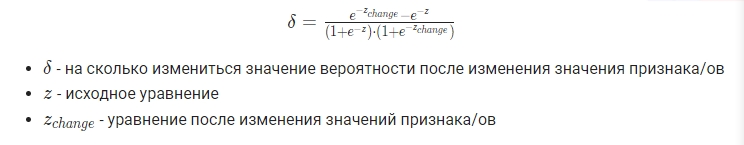

In [14]:
delta = (np.exp(-z_change[0]) - np.exp(-z[0])) / \
    ((1+np.exp(-z[0]))*(1 + np.exp(-z_change[0])))
check = round(risk - delta, 4)

print(f'Delta = {delta}')
print(
    f'Проверка, что вероятность изменилась на delta: {check == round(risk_change, 4)}'
)

Delta = 0.01020563589913441
Проверка, что вероятность изменилась на delta: True


Таким образом можно прогнозировать изменения вероятностей.